In [228]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [229]:
file_path = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML\refund_sessions.csv"
df = pd.read_csv(file_path, low_memory=False)

In [176]:
#df=df[df['session_dt']!="session_dt"]
##df[df['session_dt'].isna()]
print(df.columns)
#print(df.dtypes)
#print(df.describe())

Index(['session_id', 'session_dt', 'year1', 'month1', 'wk1', 'incident_id',
       'customer_id', 'issue_type', 'sub_issue_type', 'sub_sub_issue_type',
       'ssi', 'deliverygroup', 'LOB', 'FRM_OCR_Flag', 'order_external_id',
       'order_item_id', 'initial_promise_date_time', 'final_promise_date_time',
       'is_shopsy_order', 'marketplace_id', 'order_status', 'refund_status',
       'Refund_completion_flag', 'refund_final_status_updated', 'refund_mode',
       'payment_mode', 'instrument_type', 'payment_instrument',
       'refund_reason', 'refund_reason_flag', 'ref_amount_flag',
       'transaction_source', 'ARN_ISSUE_FLAG', 'void_flag', 'pg_id',
       'bank_name', 'order_id', 'parent_refund_id', 'child_refund_id',
       'parent_created_at', 'completed_time', 'Refund_completion_flag1',
       'delivery_tat_variance', 'created_completed_variance', 'refund_lag_Day',
       'refund_lag_hrs', 'is_rto', 'loyalty_segment', 'customer_value_segment',
       'total_orders_customers', 't

In [191]:
print(len(df.columns))

70


In [173]:
import missingno as msno
import matplotlib.pyplot as plt

<Figure size 1000x500 with 0 Axes>

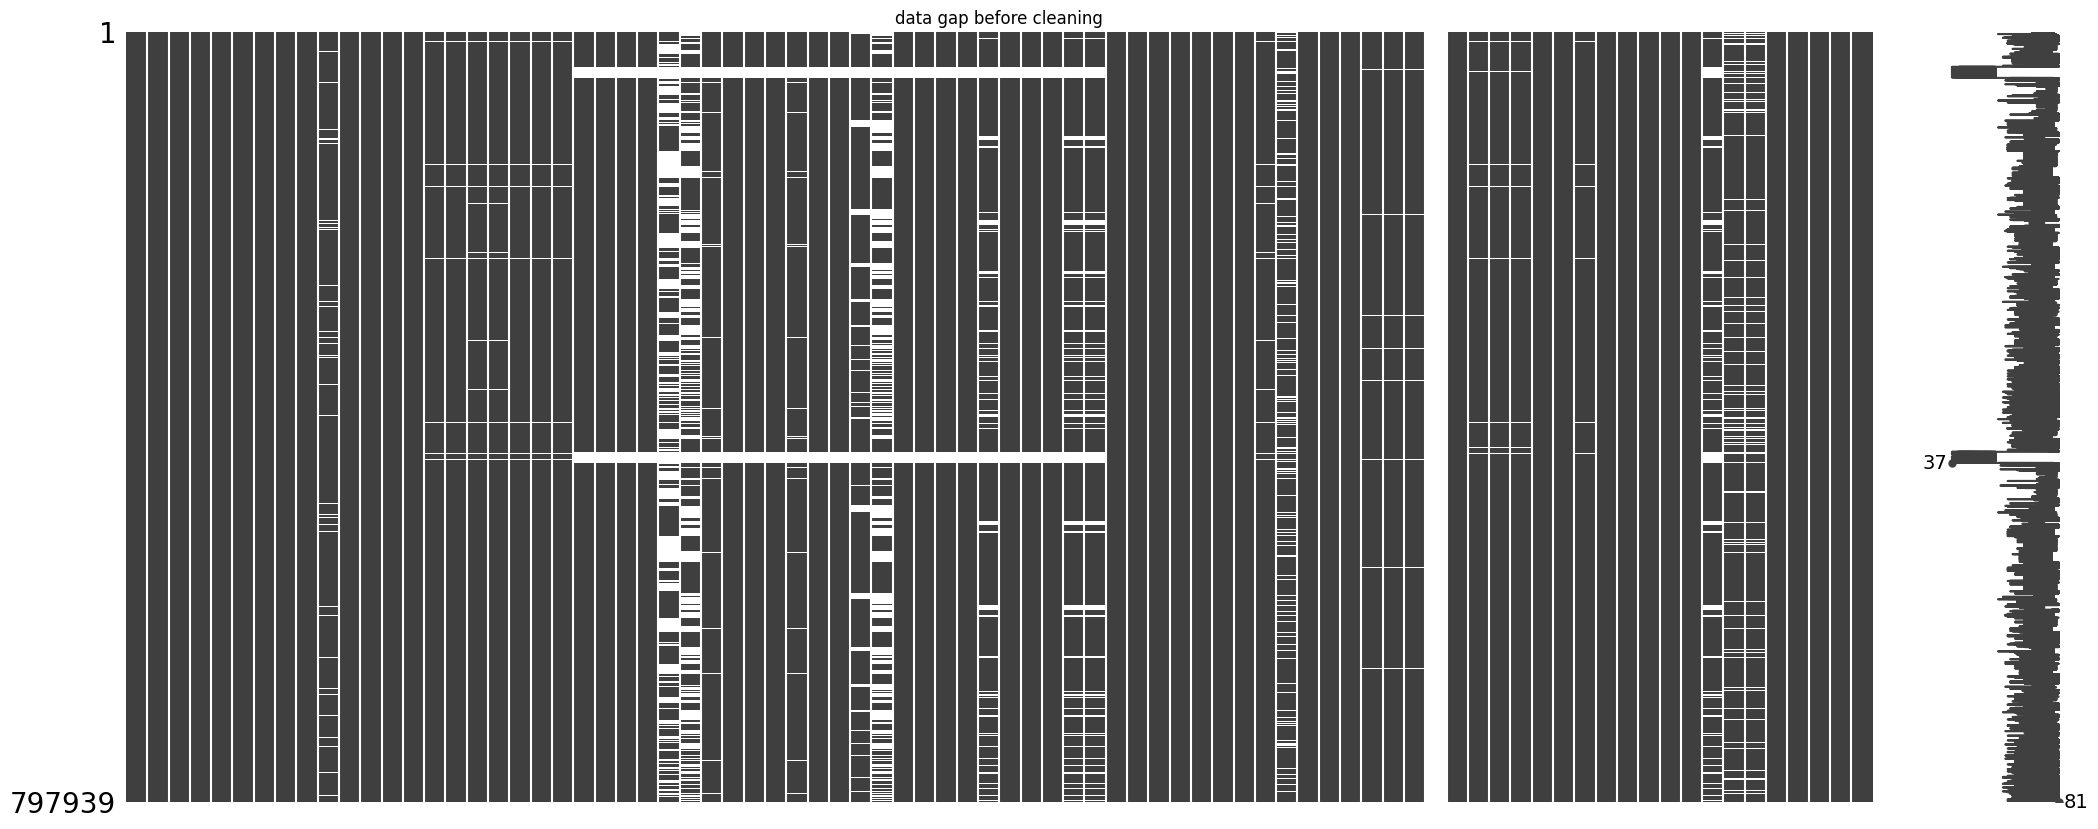

In [181]:
plt.figure(figsize=(10,5))
#feature_cols = ['SLA_last_breach', 'delivery_tat_breach', 'revenue_growth_wow',
#       'is_fcr', 'is_repeat', 'is_reopened', 'overall_resolution_time',
#       'reopen_resolution_time', 'resolution_time_hrs', 'sla_breach_hrs',
#       'report_date', 'daily_gmv', 'AOV', 'ASP', 'conversion_rate', 'DAU',
#       'return_rate', 'FCR_rate', 'repeat_rate', 'contact_to_refund_bucket',
#       'contact_to_complete_bucket', 'contact_to_SLA_bucket',
#       'init_completion_flag', 'pymnt_cnt', 'payment_type_final'
#       ]
#msno.matrix(df[feature_cols])
msno.matrix(df)
plt.title("data gap before cleaning")
plt.show()


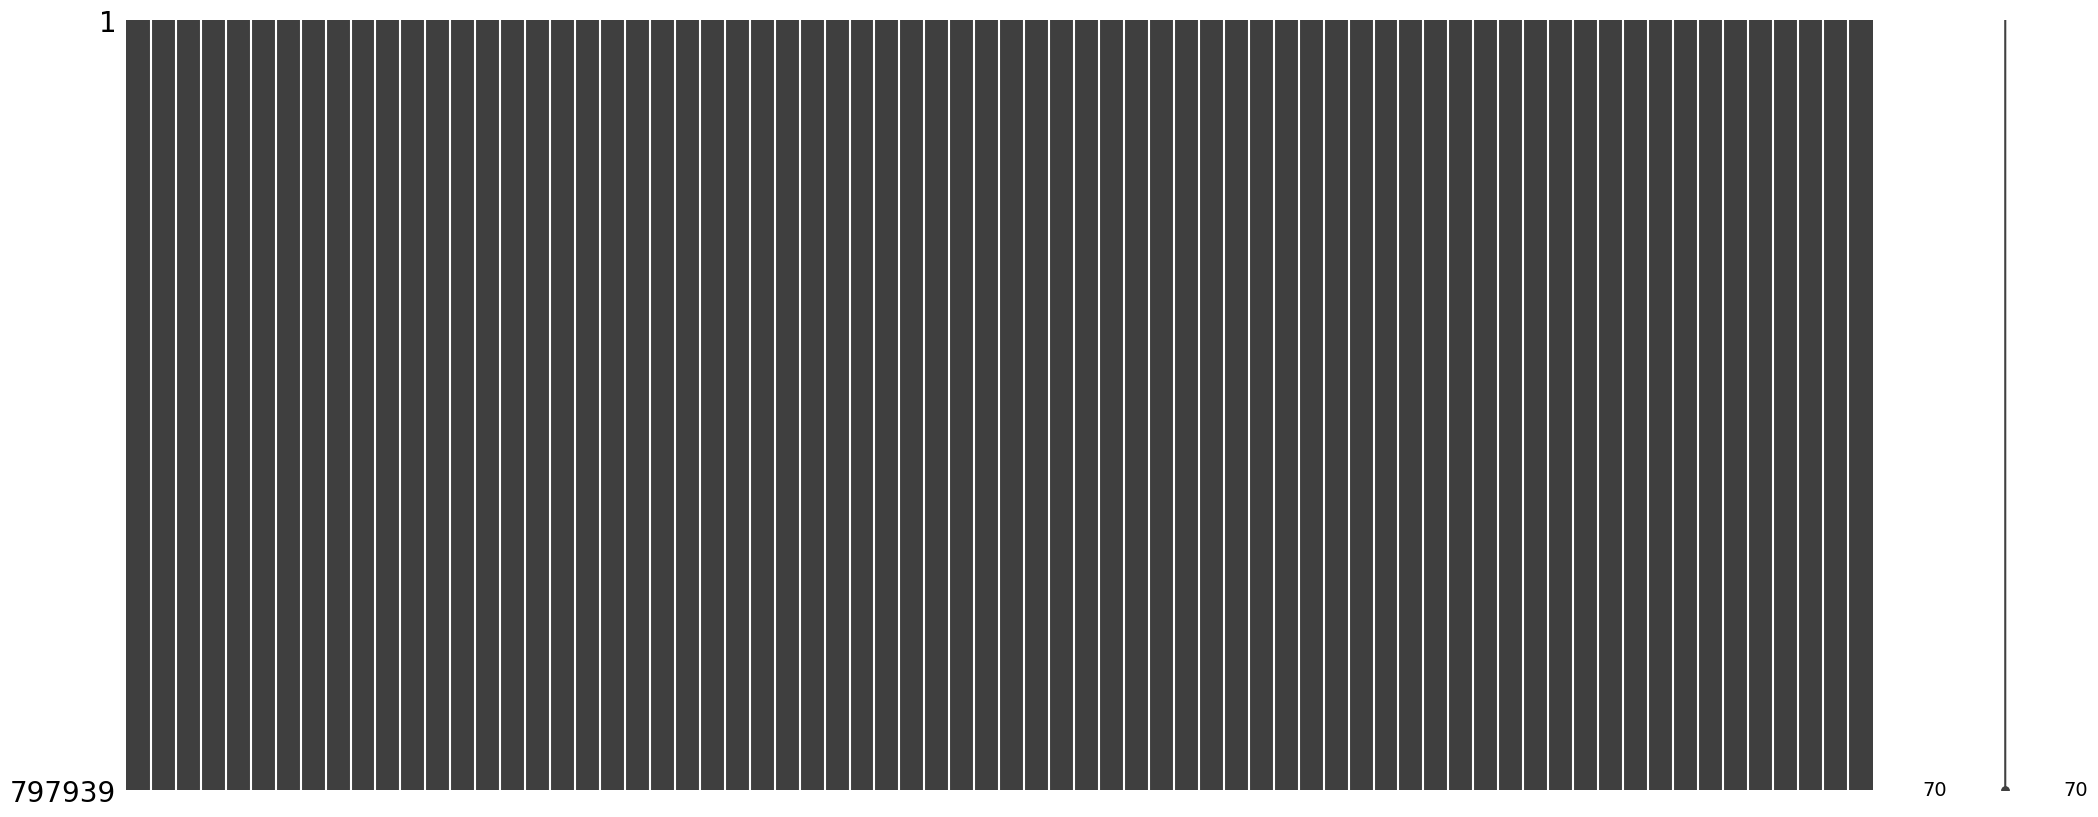

In [184]:
limit =len(df) *0.9
df=df.dropna(thresh = limit, axis=1)

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(-1)
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('unknown')

msno.matrix(df)
plt.show()


In [186]:
print(df.isnull().sum().sum())
#print(df.isnull().sum().sum())

0


In [190]:
print(len(df.columns))

70


In [205]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, export_text

exclude = ['session_id', 'incident_id', 'order_external_id', 'ucid','year1', 'month1', 'order_id','customer_id','session_dt','report_date',
           'initial_promise_date_time','final_promise_date_time','RNK','inc_cnt', 'odr_cnt', 'acct_cnt']
target = ['contacts']
feature_cols  = [c for c in df.columns if c not in exclude and c not in target]
df_ml = df[feature_cols + target].copy()

for col in feature_cols:
    if df_ml[col].dtype == 'object':
        le= LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        
X = df_ml[feature_cols]
y = df_ml[target]

dt_model = DecisionTreeRegressor(max_depth=4,random_state=42)
dt_model.fit(X, y)

print("Decision Tree inference (increase/decrease):")
print(export_text(dt_model, feature_names=feature_cols))

Decision Tree inference (increase/decrease):
|--- value: [1.00]



In [216]:
group_cols = [
    'wk1', 'issue_type', 'sub_issue_type', 'sub_sub_issue_type',
    'ssi', 'deliverygroup',  'order_status', 
    'refund_status', 'Refund_completion_flag', 'refund_mode',
    'payment_instrument', 'refund_reason', 
    'loyalty_segment', 'customer_value_segment', 'is_rto', 
    'contact_to_refund_bucket', 'contact_to_SLA_bucket'
]
df_agg = df.groupby(group_cols)['contacts'].sum().reset_index()
df_ml = df_agg.copy()
le = LabelEncoder()
for col in group_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

X = df_ml[group_cols]
y=df_ml['contacts']
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X,y)

print(export_text(dt_model, feature_names=group_cols))


|--- contact_to_refund_bucket <= 1.50
|   |--- sub_sub_issue_type <= 0.50
|   |   |--- refund_mode <= 18.50
|   |   |   |--- is_rto <= 0.50
|   |   |   |   |--- value: [2.71]
|   |   |   |--- is_rto >  0.50
|   |   |   |   |--- value: [20.85]
|   |   |--- refund_mode >  18.50
|   |   |   |--- customer_value_segment <= 1.50
|   |   |   |   |--- value: [35.86]
|   |   |   |--- customer_value_segment >  1.50
|   |   |   |   |--- value: [78.99]
|   |--- sub_sub_issue_type >  0.50
|   |   |--- sub_sub_issue_type <= 2.50
|   |   |   |--- order_status <= 6.50
|   |   |   |   |--- value: [13.68]
|   |   |   |--- order_status >  6.50
|   |   |   |   |--- value: [4.57]
|   |   |--- sub_sub_issue_type >  2.50
|   |   |   |--- sub_issue_type <= 1.00
|   |   |   |   |--- value: [4.55]
|   |   |   |--- sub_issue_type >  1.00
|   |   |   |   |--- value: [2.02]
|--- contact_to_refund_bucket >  1.50
|   |--- contact_to_SLA_bucket <= 8.50
|   |   |--- deliverygroup <= 0.50
|   |   |   |--- sub_issue_typ

In [217]:
for col in ['wk1', 'issue_type', 'sub_issue_type', 'sub_sub_issue_type',
    'ssi', 'deliverygroup',  'order_status', 
    'refund_status', 'Refund_completion_flag', 'refund_mode',
    'payment_instrument', 'refund_reason', 
    'loyalty_segment', 'customer_value_segment', 'is_rto', 
    'contact_to_refund_bucket', 'contact_to_SLA_bucket']:
    le = LabelEncoder()
    le.fit(df_agg[col].astype(str))
    print(f"\nClasses for {col}:")
    for i, category in enumerate(le.classes_):
        print(f"{i}: {category}")




Classes for wk1:
0: 40
1: 41
2: 42
3: 43
4: 44
5: 45
6: 46
7: 47
8: 48
9: 49
10: 50
11: 51
12: 52

Classes for issue_type:
0: Refund Follow-ups
1: Refunds

Classes for sub_issue_type:
0: Gathered Offline Refund Details
1: Refund Related Enquiry
2: Refund Related Issues

Classes for sub_sub_issue_type:
0: Cancellation done but refund pending
1: Refund Failed/cancelled
2: Refund Status Enquiry
3: Refund Status Related
4: Refund completed but not reflecting
5: Refund stuck_Int/processing
6: Return Override
7: unknown

Classes for ssi:
0: Refund Follow-ups->Gathered Offline Refund Details->NA
1: Refunds->Refund Related Enquiry->Refund Status Enquiry
2: Refunds->Refund Related Issues->Cancellation done but refund pending
3: Refunds->Refund Related Issues->Refund Failed/cancelled
4: Refunds->Refund Related Issues->Refund Status Related
5: Refunds->Refund Related Issues->Refund completed but not reflecting
6: Refunds->Refund Related Issues->Refund stuck_Int/processing
7: Refunds->Refund Rela

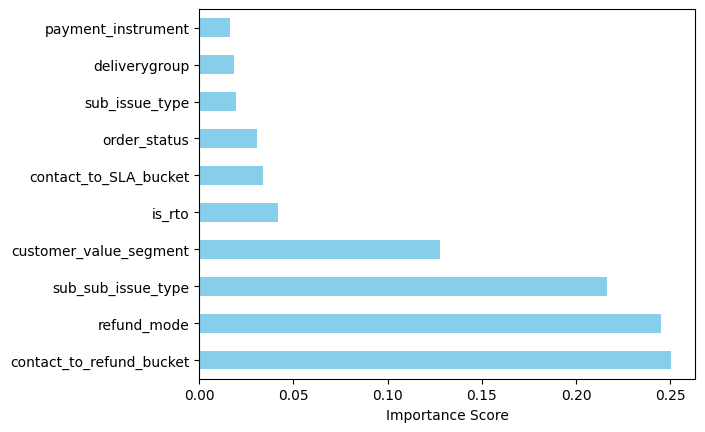

In [219]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(dt_model.feature_importances_, index=group_cols)
importances.nlargest(10).plot(kind='barh', color ='skyblue')
plt.title = ('Top ten drivers of contacts')
plt.xlabel('Importance Score')
plt.show()

In [224]:
df_ml['node_id'] = dt_model.apply(X)
node_analysis = df_agg.copy()
node_analysis['node_id'] = df_ml['node_id']
top_pain_points = node_analysis.groupby('node_id').agg({
    'contacts': 'mean',
    'issue_type': lambda x: x.mode()[0],
    'refund_mode': lambda x: x.mode()[0],
    'is_rto': lambda x: x.mode()[0],
    'contact_to_refund_bucket': lambda x: x.mode()[0]
}).sort_values(by='contacts',ascending=False)
print('Top 5 nodes driving contacts')
print(top_pain_points.head(10))
    

Top 5 nodes driving contacts
          contacts         issue_type  refund_mode  is_rto  \
node_id                                                      
8        78.988136            Refunds   UPI_INTENT       0   
7        35.860109            Refunds   UPI_INTENT       1   
5        20.854441            Refunds         COIN       1   
27       16.529384            Refunds         IMPS       0   
11       13.684402            Refunds   UPI_INTENT       0   
26        8.124581            Refunds  CREDIT_CARD       0   
30        7.622366            Refunds   UPI_INTENT       0   
19        5.352796            Refunds   UPI_INTENT       0   
12        4.565292            Refunds   UPI_INTENT       0   
14        4.546672  Refund Follow-ups         IMPS       0   

        contact_to_refund_bucket  
node_id                           
8                  1. Pre_Refund  
7                  1. Pre_Refund  
5                  1. Pre_Refund  
27                    9. >72 Hrs  
11              

In [227]:
df_ml['node_id'] = dt_model.apply(X)
node_means = df_ml.groupby('node_id')[target[0]].mean()
worst_node_id = node_means.idxmax()
worst_case_samples = df_agg[df_ml['node_id']==worst_node_id]

print(f"Data for K Node {worst_node_id} (The {node_means.max():.2f} contacts group):")
print(worst_case_samples.head(10))

Data for K Node 8 (The 78.99 contacts group):
      wk1 issue_type         sub_issue_type  \
6294   40    Refunds  Refund Related Issues   
6305   40    Refunds  Refund Related Issues   
6373   40    Refunds  Refund Related Issues   
6386   40    Refunds  Refund Related Issues   
6393   40    Refunds  Refund Related Issues   
6398   40    Refunds  Refund Related Issues   
6400   40    Refunds  Refund Related Issues   
6401   40    Refunds  Refund Related Issues   
6437   40    Refunds  Refund Related Issues   
6438   40    Refunds  Refund Related Issues   

                        sub_sub_issue_type  \
6294  Cancellation done but refund pending   
6305  Cancellation done but refund pending   
6373  Cancellation done but refund pending   
6386  Cancellation done but refund pending   
6393  Cancellation done but refund pending   
6398  Cancellation done but refund pending   
6400  Cancellation done but refund pending   
6401  Cancellation done but refund pending   
6437  Cancellation don